In [1]:
%run 00_setup.ipynb

### Carregar a exportação

In [2]:
RUN_ID = REFERENCE_RUN   # = 2, a execucao de referencia (a adjudicada); mude para analisar outra
ann    = load("annotations.csv", run=RUN_ID)
gold   = load("gold.csv", run=RUN_ID)
status = load("status.csv", run=RUN_ID)
fail   = load("failures.csv", run=RUN_ID)
dist   = load("pattern_distribution.csv", run=RUN_ID)
sample = load("sample.csv", run=RUN_ID)
meta   = load("meta.csv", run=RUN_ID).iloc[0].to_dict()

print(f"run {RUN_ID}: {meta['label']}  |  painel: {meta['panel']}")
print(f"{len(ann)} linhas de anotacao, {len(gold)} linhas de gold, {len(status)} linhas de estado, {len(fail)} linhas de falha")

run 2: llm_panel #2  |  painel: deepseek/deepseek-v4-flash;meta-llama/llama-3.3-70b-instruct;openai/gpt-oss-120b;qwen/qwen3-next-80b-a3b-instruct
67317 linhas de anotacao, 5000 linhas de gold, 3600 linhas de estado, 57 linhas de falha


### Prevalência por padrão

In [3]:
g = ann.groupby(["individualId", "code"])["present"]
maj = (g.sum() * 2 > g.count())            # presente por maioria estrita, por (revisao, padrao)
nrev = ann["individualId"].nunique()
prev = maj.groupby("code").sum().astype(int)
prevtab = pd.DataFrame({"reviews_flagged": prev, "rate_pct": (prev / nrev * 100).round(1)}).sort_values("reviews_flagged", ascending=False)
prevtab

,reviews_flagged,rate_pct
code,,
TM-1,52,5.8
PM-1,52,5.8
PM-3,9,1.0
DR-2,7,0.8
PE-1,5,0.6
SE-3,5,0.6
PM-4,4,0.4
PM-5,3,0.3
DR-1,3,0.3


gravado: figures/fig-prevalencia.png


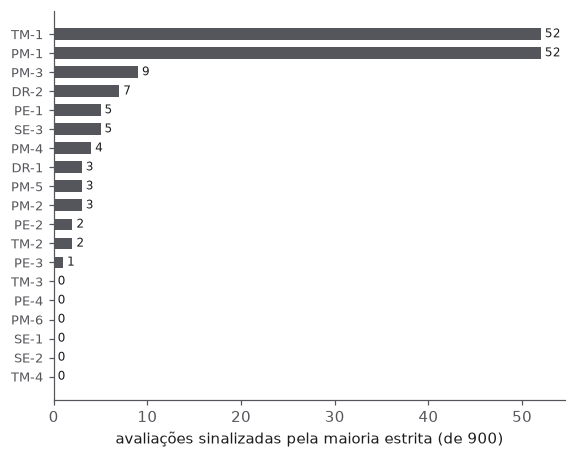

In [5]:
plt = styled_plt()
t = prevtab.sort_values("reviews_flagged")   # maiores no topo do grafico
ys = range(len(t))
fig, ax = plt.subplots(figsize=(6.0, 4.6))
ax.barh(ys, t["reviews_flagged"], height=0.62, color=MID)
ax.set_yticks(list(ys)); ax.set_yticklabels(t.index, fontsize=8.5)
for y, v in zip(ys, t["reviews_flagged"]):
    ax.annotate(f" {int(v)}", (v, y), va="center", fontsize=8, color=INK)
ax.set_xlabel(f"avaliações sinalizadas pela maioria estrita (de {nrev})")
save_fig(fig, "fig-prevalencia")

## Equilíbrio de classes
A unidade de análise é a célula (revisão × padrão). Que fracção das células é positiva (sinalizada pela maioria)?

In [6]:
print(f"celulas positivas pela maioria: {int(maj.sum())} / {len(maj)} = {100 * maj.mean():.2f}%")
zero = sorted(set(ann["code"].unique()) - set(prev[prev > 0].index))
print(f"padroes nunca sinalizados pela maioria ({len(zero)}): {zero}")

celulas positivas pela maioria: 148 / 17100 = 0.87%
padroes nunca sinalizados pela maioria (6): ['PE-4', 'PM-6', 'SE-1', 'SE-2', 'TM-3', 'TM-4']


### Perfil de detecção por jogo

Onde reside o sinal? 
O ficheiro `pattern_distribution.csv` conta, por jogo, quantas revisões uma maioria do painel sinalizou para cada padrão.

In [7]:
dist.groupby("gameName")["reviews"].sum().sort_values(ascending=False)

gameName
World of Warships    67
Warframe             55
Path of Exile II     26
Name: reviews, dtype: int64

In [8]:
dist.sort_values("reviews", ascending=False).head(8)[["gameName", "code", "reviews"]]

,gameName,code,reviews
118,Warframe,TM-1,33
126,World of Warships,PM-1,32
119,Warframe,PM-1,14
127,World of Warships,TM-1,10
136,Path of Exile II,TM-1,9
128,World of Warships,PM-3,9
137,Path of Exile II,PM-1,6
129,World of Warships,SE-3,5


> Os jogos diferem em quanta (e qual) manipulação surge nas suas revisões. A maior célula isolada é o padrão de monetização de um dado jogo. Esta leitura por jogo é o esqueleto descritivo da QI1 (que padrões são observáveis no texto das revisões).